CS 175 PROJECT

1) SETUP AND IMPORTS


In [1]:
!pip -q install datasets transformers accelerate scikit-learn

import time, random, numpy as np, pandas as pd
from datasets import load_dataset

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, roc_auc_score, log_loss

import torch
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification, get_linear_schedule_with_warmup


2) Reproducibility

In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
device


'cuda'

3) Load IMDB + split train/val/test

In [3]:
# 3. Load IMDB + split train/val/test

from datasets import load_dataset
import numpy as np

ds = load_dataset("imdb")  # official train/test

# Convert to normal Python lists (IMPORTANT FIX)
train_texts = list(ds["train"]["text"])
train_labels = np.array(ds["train"]["label"])

test_texts = list(ds["test"]["text"])
test_labels = np.array(ds["test"]["label"])

# validation split from train
val_size = 5000
perm = np.random.permutation(len(train_texts))

val_idx = perm[:val_size]
tr_idx  = perm[val_size:]

# Convert numpy int64 -> python int when indexing
tr_texts = [train_texts[int(i)] for i in tr_idx]
tr_y     = train_labels[tr_idx]

val_texts = [train_texts[int(i)] for i in val_idx]
val_y     = train_labels[val_idx]

print("Train:", len(tr_texts))
print("Validation:", len(val_texts))
print("Test:", len(test_texts))

# SPEED OPTION (optional)
SUBSAMPLE = 12000
tr_texts_small = tr_texts[:SUBSAMPLE]
tr_y_small     = tr_y[:SUBSAMPLE]


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Train: 20000
Validation: 5000
Test: 25000


4) Baselines: TF-IDF + Logistic Regression + Calibrated SVM

In [4]:
#Cell 4A — metric helper

def basic_metrics(y_true, p_pos):
    y_true = np.asarray(y_true)
    p_pos = np.asarray(p_pos)
    y_pred = (p_pos >= 0.5).astype(int)

    acc = accuracy_score(y_true, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="binary", zero_division=0)
    auc = roc_auc_score(y_true, p_pos)
    nll = log_loss(y_true, np.clip(p_pos, 1e-7, 1 - 1e-7))
    return {"accuracy": acc, "precision": prec, "recall": rec, "f1": f1, "roc_auc": auc, "nll": nll}


In [5]:
#Cell 4B — TF-IDF + models

# TF-IDF features
vectorizer = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1, 2),
    stop_words="english"
)

X_tr  = vectorizer.fit_transform(tr_texts_small)
X_val = vectorizer.transform(val_texts)
X_te  = vectorizer.transform(test_texts)

results = []

# Logistic Regression baseline
t0 = time.perf_counter()
lr = LogisticRegression(max_iter=2000)
lr.fit(X_tr, tr_y_small)
lr_train_time = time.perf_counter() - t0

val_lr = lr.predict_proba(X_val)[:, 1]
te_lr  = lr.predict_proba(X_te)[:, 1]

results.append({"model":"LogReg TF-IDF", "split":"val",  **basic_metrics(val_y, val_lr), "train_s": lr_train_time})
results.append({"model":"LogReg TF-IDF", "split":"test", **basic_metrics(test_labels, te_lr), "train_s": lr_train_time})

# Calibrated SVM baseline (SVM + sigmoid calibration so we get probabilities)
t0 = time.perf_counter()
svm = LinearSVC()
cal_svm = CalibratedClassifierCV(svm, method="sigmoid", cv=3)
cal_svm.fit(X_tr, tr_y_small)
svm_train_time = time.perf_counter() - t0

val_svm = cal_svm.predict_proba(X_val)[:, 1]
te_svm  = cal_svm.predict_proba(X_te)[:, 1]

results.append({"model":"Calibrated SVM TF-IDF", "split":"val",  **basic_metrics(val_y, val_svm), "train_s": svm_train_time})
results.append({"model":"Calibrated SVM TF-IDF", "split":"test", **basic_metrics(test_labels, te_svm), "train_s": svm_train_time})

pd.DataFrame(results)


,model,split,accuracy,precision,recall,f1,roc_auc,nll,train_s
0,LogReg TF-IDF,val,0.87540,0.859459,0.895775,0.877241,0.951813,0.366017,1.239407
1,LogReg TF-IDF,test,0.87096,0.866735,0.876720,0.871699,0.944999,0.380712,1.239407
2,Calibrated SVM TF-IDF,val,0.88220,0.872935,0.892958,0.882833,0.956429,0.269428,0.760373
3,Calibrated SVM TF-IDF,test,0.87460,0.877956,0.870160,0.874041,0.947116,0.295478,0.760373


5) DistilBERT Setup

In [6]:
# 5. DistilBERT Setup

MODEL_NAME = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

class TextDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=256):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding="max_length",
            max_length=self.max_len,
            return_tensors="pt"
        )
        item = {k: v.squeeze(0) for k, v in enc.items()}
        item["labels"] = torch.tensor(int(self.labels[idx]), dtype=torch.long)
        return item

print("device:", device)

MAX_LEN = 256
BATCH = 16

tr_ds = TextDataset(tr_texts_small, tr_y_small, tokenizer, MAX_LEN)
va_ds = TextDataset(val_texts, val_y, tokenizer, MAX_LEN)
te_ds = TextDataset(test_texts, test_labels, tokenizer, MAX_LEN)

tr_loader = DataLoader(tr_ds, batch_size=BATCH, shuffle=True, num_workers=2, pin_memory=True)
va_loader = DataLoader(va_ds, batch_size=BATCH, shuffle=False, num_workers=2, pin_memory=True)
te_loader = DataLoader(te_ds, batch_size=BATCH, shuffle=False, num_workers=2, pin_memory=True)

model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=2,
    ignore_mismatched_sizes=True
).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

device: cuda


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [7]:
#sanity check

print(type(model))
print("num_labels:", model.config.num_labels)


<class 'transformers.models.distilbert.modeling_distilbert.DistilBertForSequenceClassification'>
num_labels: 2


5.1 Train DistilBERT (1 epoch)

In [8]:
from transformers import get_linear_schedule_with_warmup
import time
import torch

EPOCHS = 1
total_steps = EPOCHS * len(tr_loader)

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps
)

def train_one_epoch(model, loader):
    model.train()
    total_loss = 0.0
    t0 = time.perf_counter()

    for batch in loader:
        batch = {k: v.to(device) for k, v in batch.items()}
        out = model(**batch)
        loss = out.loss

        loss.backward()
        optimizer.step()
        scheduler.step()
        optimizer.zero_grad(set_to_none=True)

        total_loss += float(loss.detach().cpu())

    print("Train time (s):", round(time.perf_counter() - t0, 2))
    return total_loss / len(loader)

train_loss = train_one_epoch(model, tr_loader)
print("Train loss:", train_loss)


Train time (s): 267.03
Train loss: 0.3312180280784766


5.2 Evaluate + save logits (logits needed for temperature scaling)

In [9]:
@torch.no_grad()
def get_logits(model, loader):
    model.eval()
    all_logits = []
    for batch in loader:
        batch = {k: v.to(device) for k, v in batch.items()}
        logits = model(**batch).logits
        all_logits.append(logits.detach().cpu())
    return torch.cat(all_logits, dim=0)

val_logits = get_logits(model, va_loader)
test_logits = get_logits(model, te_loader)

val_probs = torch.softmax(val_logits, dim=-1)[:, 1].numpy()
test_probs = torch.softmax(test_logits, dim=-1)[:, 1].numpy()

print("DistilBERT val:", basic_metrics(val_y, val_probs))
print("DistilBERT test:", basic_metrics(test_labels, test_probs))


DistilBERT val: {'accuracy': 0.9012, 'precision': 0.8955105284068335, 'recall': 0.9070422535211268, 'f1': 0.9012395041983207, 'roc_auc': np.float64(0.9652221079958878), 'nll': 0.24169682790633773}
DistilBERT test: {'accuracy': 0.89836, 'precision': 0.8853207459568212, 'recall': 0.91528, 'f1': 0.9000511347991976, 'roc_auc': np.float64(0.9652951167999999), 'nll': 0.24285020030118848}


6. Temperature Scaling

In [10]:
#collect_logits_and_labels

@torch.no_grad()
def collect_logits_and_labels(model, loader, device):
    """
    Runs model in evaluation mode and collects:
    - raw logits
    - true labels
    """
    model.eval()
    all_logits, all_labels = [], []

    for batch in loader:
        batch = {k: v.to(device) for k, v in batch.items()}
        out = model(**batch)

        all_logits.append(out.logits.detach().cpu())
        all_labels.append(batch["labels"].detach().cpu())

    return torch.cat(all_logits, dim=0), torch.cat(all_labels, dim=0)


In [11]:
#expected calibration error (ece)

def expected_calibration_error(probs, labels, n_bins=20):
    """
    Computes Expected Calibration Error (ECE).

    probs  : (N, C) predicted probabilities
    labels : (N,) true labels
    n_bins : number of confidence bins
    """
    confidences = probs.max(axis=1)
    predictions = probs.argmax(axis=1)
    accuracies = (predictions == labels).astype(np.float32)

    bin_edges = np.linspace(0.0, 1.0, n_bins + 1)
    ece = 0.0

    for i in range(n_bins):
        lo, hi = bin_edges[i], bin_edges[i + 1]

        if i == n_bins - 1:
            mask = (confidences >= lo) & (confidences <= hi)
        else:
            mask = (confidences >= lo) & (confidences < hi)

        if mask.sum() == 0:
            continue

        bin_acc = accuracies[mask].mean()
        bin_conf = confidences[mask].mean()
        bin_weight = mask.mean()

        ece += np.abs(bin_acc - bin_conf) * bin_weight

    return float(ece)


In [12]:
#Temperature Scaling Module

import torch.nn as nn
import torch.nn.functional as F

class TemperatureScaler(nn.Module):
    """
    Learns a single temperature parameter T
    to calibrate model logits.
    """
    def __init__(self, init_temp=1.0):
        super().__init__()
        self.log_temp = nn.Parameter(
            torch.tensor([np.log(init_temp)], dtype=torch.float32)
        )

    def forward(self, logits):
        T = torch.exp(self.log_temp)   # ensures T > 0
        return logits / T

    def temperature(self):
        return float(torch.exp(self.log_temp).item())


def fit_temperature(val_logits, val_labels, device, max_iter=50):
    val_logits = val_logits.to(device)
    val_labels = val_labels.to(device)

    scaler = TemperatureScaler().to(device)

    optimizer = torch.optim.LBFGS(
        [scaler.log_temp],
        lr=0.1,
        max_iter=max_iter
    )

    def closure():
        optimizer.zero_grad()
        loss = F.cross_entropy(scaler(val_logits), val_labels)
        loss.backward()
        return loss

    optimizer.step(closure)
    return scaler


In [13]:
#run and compute

val_logits, val_labels = collect_logits_and_labels(model, va_loader, device)
test_logits, test_labels = collect_logits_and_labels(model, te_loader, device)
val_probs = torch.softmax(val_logits, dim=1).numpy()
test_probs = torch.softmax(test_logits, dim=1).numpy()

val_y = val_labels.numpy()
test_y = test_labels.numpy()

ece_orig_val = expected_calibration_error(val_probs, val_y, n_bins=20)
ece_orig_test = expected_calibration_error(test_probs, test_y, n_bins=20)

scaler = fit_temperature(val_logits, val_labels, device=device)
T_star = scaler.temperature()

val_probs_cal = torch.softmax(
    scaler(val_logits.to(device)).detach().cpu(),
    dim=1
).numpy()

test_probs_cal = torch.softmax(
    scaler(test_logits.to(device)).detach().cpu(),
    dim=1).numpy()

ece_cal_val = expected_calibration_error(val_probs_cal, val_y, n_bins=20)
ece_cal_test = expected_calibration_error(test_probs_cal, test_y, n_bins=20)

print("Learned temperature T* =", T_star)
print("ECE (val)  original:", ece_orig_val, " calibrated:", ece_cal_val)
print("ECE (test) original:", ece_orig_test, " calibrated:", ece_cal_test)


Learned temperature T* = 0.979653537273407
ECE (val)  original: 0.01362798933982849  calibrated: 0.013329775822162628
ECE (test) original: 0.01376071046590805  calibrated: 0.014500215702056883


7. added DistilBERT to unified table (TA suggestion from week 6)

In [14]:
distil_train_time = 265.12  # use your printed train time

#original
results.append({
    "model": "DistilBERT",
    "split": "val",
    **basic_metrics(val_y, val_probs[:, 1]),
    "train_s": distil_train_time
})

results.append({
    "model": "DistilBERT",
    "split": "test",
    **basic_metrics(test_y, test_probs[:, 1]),
    "train_s": distil_train_time
})

# calibrated
results.append({
    "model": "DistilBERT + Temp",
    "split": "val",
    **basic_metrics(val_y, val_probs_cal[:, 1]),
    "train_s": distil_train_time
})

results.append({
    "model": "DistilBERT + Temp",
    "split": "test",
    **basic_metrics(test_y, test_probs_cal[:, 1]),
    "train_s": distil_train_time
})

#final table
final_df = pd.DataFrame(results)
final_df.sort_values(["model", "split"])

final_df = pd.DataFrame(results)

# remove duplicate rows
final_df = final_df.drop_duplicates()
final_df.sort_values(["model", "split"])



,model,split,accuracy,precision,recall,f1,roc_auc,nll,train_s
3,Calibrated SVM TF-IDF,test,0.87460,0.877956,0.870160,0.874041,0.947116,0.295478,0.760373
2,Calibrated SVM TF-IDF,val,0.88220,0.872935,0.892958,0.882833,0.956429,0.269428,0.760373
5,DistilBERT,test,0.89836,0.885321,0.915280,0.900051,0.965295,0.242850,265.120000
4,DistilBERT,val,0.90120,0.895511,0.907042,0.901240,0.965222,0.241697,265.120000
7,DistilBERT + Temp,test,0.89836,0.885321,0.915280,0.900051,0.965295,0.242808,265.120000
6,DistilBERT + Temp,val,0.90120,0.895511,0.907042,0.901240,0.965222,0.241631,265.120000
1,LogReg TF-IDF,test,0.87096,0.866735,0.876720,0.871699,0.944999,0.380712,1.239407
0,LogReg TF-IDF,val,0.87540,0.859459,0.895775,0.877241,0.951813,0.366017,1.239407


8. reliability diagram (before vs after) (TA suggestion from week 6)

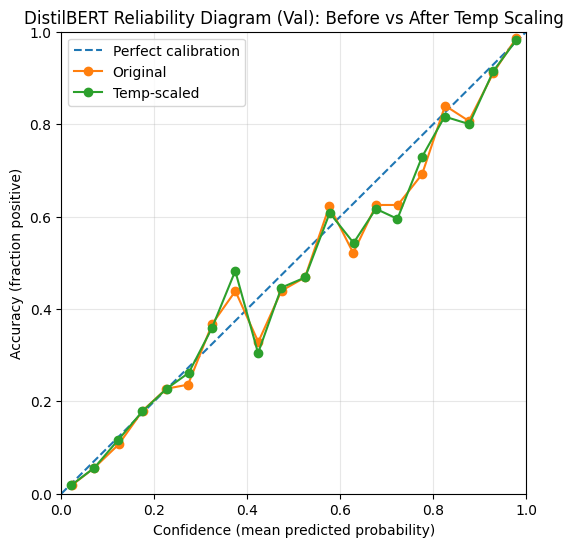

In [15]:
import numpy as np
import matplotlib.pyplot as plt

def reliability_curve(probs_pos, y_true, n_bins=20):
    """
    probs_pos: shape (N,) predicted probability for positive class
    y_true:    shape (N,) 0/1 labels
    Returns:
      bin_centers, acc_in_bin, conf_in_bin, counts
    """
    probs_pos = np.asarray(probs_pos)
    y_true = np.asarray(y_true)

    bins = np.linspace(0.0, 1.0, n_bins + 1)
    bin_ids = np.digitize(probs_pos, bins) - 1
    bin_ids = np.clip(bin_ids, 0, n_bins - 1)

    acc_in_bin = np.zeros(n_bins)
    conf_in_bin = np.zeros(n_bins)
    counts = np.zeros(n_bins, dtype=int)

    for b in range(n_bins):
        mask = bin_ids == b
        counts[b] = mask.sum()
        if counts[b] > 0:
            conf_in_bin[b] = probs_pos[mask].mean()
            acc_in_bin[b] = y_true[mask].mean()
        else:
            conf_in_bin[b] = (bins[b] + bins[b+1]) / 2.0
            acc_in_bin[b] = np.nan

    bin_centers = (bins[:-1] + bins[1:]) / 2.0
    return bin_centers, acc_in_bin, conf_in_bin, counts

def plot_reliability_before_after(probs_before, probs_after, y_true, n_bins=20, title="Reliability Diagram (Val)"):
    x_b, acc_b, conf_b, cnt_b = reliability_curve(probs_before, y_true, n_bins=n_bins)
    x_a, acc_a, conf_a, cnt_a = reliability_curve(probs_after,  y_true, n_bins=n_bins)

    # Only plot bins that have data
    mask_b = ~np.isnan(acc_b)
    mask_a = ~np.isnan(acc_a)

    plt.figure(figsize=(6, 6))
    plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")

    plt.plot(conf_b[mask_b], acc_b[mask_b], marker="o", label="Original")
    plt.plot(conf_a[mask_a], acc_a[mask_a], marker="o", label="Temp-scaled")

    plt.xlabel("Confidence (mean predicted probability)")
    plt.ylabel("Accuracy (fraction positive)")
    plt.title(title)
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

plot_reliability_before_after(
    probs_before=val_probs[:, 1],
    probs_after=val_probs_cal[:, 1],
    y_true=val_y,
    n_bins=20,
    title="DistilBERT Reliability Diagram (Val): Before vs After Temp Scaling"
)


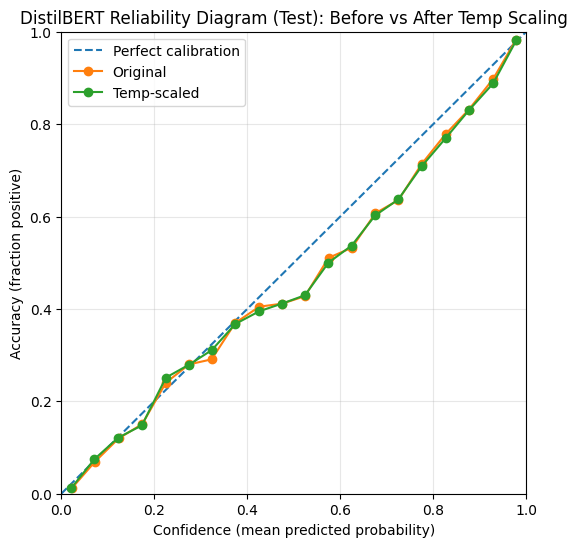

In [16]:
plot_reliability_before_after(
    probs_before=test_probs[:, 1],
    probs_after=test_probs_cal[:, 1],
    y_true=test_y,
    n_bins=20,
    title="DistilBERT Reliability Diagram (Test): Before vs After Temp Scaling"
)


9. error analysis

In [17]:
 # Prediction labels

# Logistic Regression
logreg_val_preds = (val_lr >= 0.5).astype(int)
logreg_test_preds = (te_lr >= 0.5).astype(int)

# Calibrated SVM
svm_val_preds = (val_svm >= 0.5).astype(int)
svm_test_preds = (te_svm >= 0.5).astype(int)

# DistilBERT
bert_val_preds = (val_probs[:, 1] >= 0.5).astype(int)
bert_test_preds = (test_probs[:, 1] >= 0.5).astype(int)


In [18]:
#error data frame
import pandas as pd

error_df = pd.DataFrame({
    "text": X_te,
    "true_label": test_y,
    "logreg_pred": logreg_test_preds,
    "svm_pred": svm_test_preds,
    "bert_pred": bert_test_preds,
    "bert_conf": test_probs[:, 1]
})

error_df["logreg_correct"] = error_df["logreg_pred"] == error_df["true_label"]
error_df["svm_correct"] = error_df["svm_pred"] == error_df["true_label"]
error_df["bert_correct"] = error_df["bert_pred"] == error_df["true_label"]


In [19]:
#DistilBERT misclassification
bert_errors = error_df[~error_df["bert_correct"]]

print("Total DistilBERT errors:", len(bert_errors))
bert_errors.head(5)


Total DistilBERT errors: 2541


,text,true_label,logreg_pred,svm_pred,bert_pred,bert_conf,logreg_correct,svm_correct,bert_correct
4,<Compressed Sparse Row sparse matrix of dtype ...,0,1,1,1,0.964208,False,False,False
6,<Compressed Sparse Row sparse matrix of dtype ...,0,1,1,1,0.816935,False,False,False
18,<Compressed Sparse Row sparse matrix of dtype ...,0,0,0,1,0.933259,True,True,False
20,<Compressed Sparse Row sparse matrix of dtype ...,0,1,1,1,0.848885,False,False,False
21,<Compressed Sparse Row sparse matrix of dtype ...,0,0,0,1,0.608338,True,True,False


In [20]:
# cases where LogReg correct but BERT wrong
logreg_correct_bert_wrong = error_df[
    (error_df["logreg_correct"]) &
    (~error_df["bert_correct"])
]

print("LogReg correct but BERT wrong:", len(logreg_correct_bert_wrong))
logreg_correct_bert_wrong.head(5)


LogReg correct but BERT wrong: 1352


,text,true_label,logreg_pred,svm_pred,bert_pred,bert_conf,logreg_correct,svm_correct,bert_correct
18,<Compressed Sparse Row sparse matrix of dtype ...,0,0,0,1,0.933259,True,True,False
21,<Compressed Sparse Row sparse matrix of dtype ...,0,0,0,1,0.608338,True,True,False
37,<Compressed Sparse Row sparse matrix of dtype ...,0,0,0,1,0.618143,True,True,False
56,<Compressed Sparse Row sparse matrix of dtype ...,0,0,0,1,0.523289,True,True,False
58,<Compressed Sparse Row sparse matrix of dtype ...,0,0,0,1,0.698743,True,True,False


In [21]:
# cases where "BERT correct but LogReg wrong
bert_correct_logreg_wrong = error_df[
    (error_df["bert_correct"]) &
    (~error_df["logreg_correct"])
]

print("BERT correct but LogReg wrong:", len(bert_correct_logreg_wrong))
bert_correct_logreg_wrong.head(5)


BERT correct but LogReg wrong: 2037


,text,true_label,logreg_pred,svm_pred,bert_pred,bert_conf,logreg_correct,svm_correct,bert_correct
11,<Compressed Sparse Row sparse matrix of dtype ...,0,1,1,0,0.254633,False,False,True
25,<Compressed Sparse Row sparse matrix of dtype ...,0,1,0,0,0.166196,False,True,True
39,<Compressed Sparse Row sparse matrix of dtype ...,0,1,0,0,0.070122,False,True,True
41,<Compressed Sparse Row sparse matrix of dtype ...,0,1,1,0,0.100628,False,False,True
47,<Compressed Sparse Row sparse matrix of dtype ...,0,1,0,0,0.106733,False,True,True


In [22]:
#overconfidence analysis

bert_wrong_conf = error_df.loc[
    ~error_df["bert_correct"], "bert_conf"
]

bert_correct_conf = error_df.loc[
    error_df["bert_correct"], "bert_conf"
]

print("Mean confidence (correct):", bert_correct_conf.mean())
print("Mean confidence (wrong):", bert_wrong_conf.mean())


Mean confidence (correct): 0.5118179
Mean confidence (wrong): 0.5447298


10. isotonic regression

In [23]:
# Isotonic Regression: Fit on VAL

from sklearn.isotonic import IsotonicRegression
import numpy as np

# Positive-class probabilities
val_p = val_probs[:, 1]
test_p = test_probs[:, 1]

# Fit isotonic mapping: p -> calibrated_p
iso = IsotonicRegression(out_of_bounds="clip")
iso.fit(val_p, val_y)

# Apply mapping
val_p_iso = iso.transform(val_p)
test_p_iso = iso.transform(test_p)

# Convert back to (N,2) probs for ECE
val_probs_iso = np.vstack([1 - val_p_iso, val_p_iso]).T
test_probs_iso = np.vstack([1 - test_p_iso, test_p_iso]).T

In [24]:
# Metrics: Original vs Isotonic

ece_iso_val = expected_calibration_error(val_probs_iso, val_y, n_bins=20)
ece_iso_test = expected_calibration_error(test_probs_iso, test_y, n_bins=20)

print("ECE (val)  Isotonic:", ece_iso_val)
print("ECE (test) Isotonic:", ece_iso_test)

print("VAL  Isotonic:", basic_metrics(val_y, val_p_iso))
print("TEST Isotonic:", basic_metrics(test_y, test_p_iso))


# Compare ECE across methods

ece_orig_val = expected_calibration_error(val_probs, val_y, n_bins=20)
ece_temp_val = expected_calibration_error(val_probs_cal, val_y, n_bins=20)

ece_orig_test = expected_calibration_error(test_probs, test_y, n_bins=20)
ece_temp_test = expected_calibration_error(test_probs_cal, test_y, n_bins=20)

print("ECE (val):  Original =", ece_orig_val, "| Temp =", ece_temp_val, "| Iso =", ece_iso_val)
print("ECE (test): Original =", ece_orig_test, "| Temp =", ece_temp_test, "| Iso =", ece_iso_test)

ECE (val)  Isotonic: 2.199411392211914e-08
ECE (test) Isotonic: 0.004279447114467621
VAL  Isotonic: {'accuracy': 0.9022, 'precision': 0.9030694668820679, 'recall': 0.8997987927565393, 'f1': 0.9014311630719613, 'roc_auc': np.float64(0.9663468684872655), 'nll': 0.23295578923187513}
TEST Isotonic: {'accuracy': 0.8996, 'precision': 0.893989588263133, 'recall': 0.90672, 'f1': 0.9003097942648344, 'roc_auc': np.float64(0.9649288032), 'nll': 0.244741420748504}
ECE (val):  Original = 0.01362798933982849 | Temp = 0.013329775822162628 | Iso = 2.199411392211914e-08
ECE (test): Original = 0.01376071046590805 | Temp = 0.014500215702056883 | Iso = 0.004279447114467621


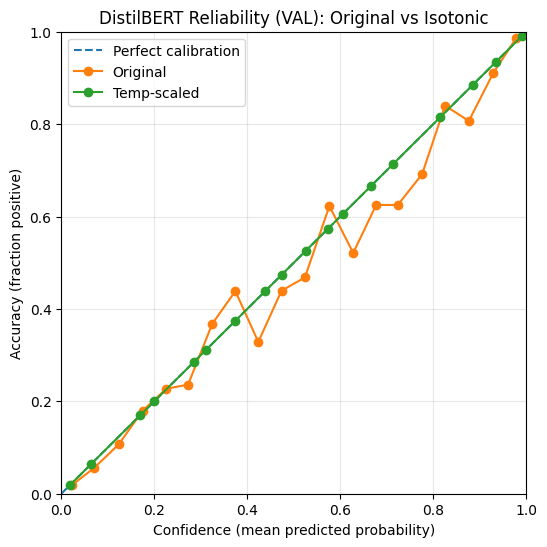

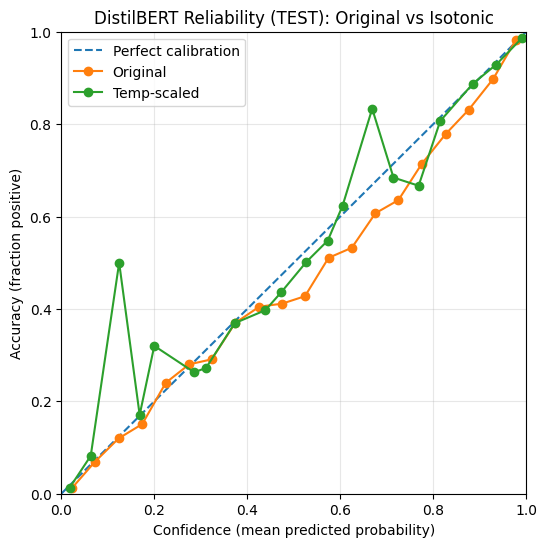

In [25]:
# Reliability Diagrams: Isotonic

plot_reliability_before_after(
    probs_before=val_probs[:, 1],
    probs_after=val_probs_iso[:, 1],
    y_true=val_y,
    n_bins=20,
    title="DistilBERT Reliability (VAL): Original vs Isotonic"
)

plot_reliability_before_after(
    probs_before=test_probs[:, 1],
    probs_after=test_probs_iso[:, 1],
    y_true=test_y,
    n_bins=20,
    title="DistilBERT Reliability (TEST): Original vs Isotonic"
)

unified table with everything

In [26]:
# Add DistilBERT + Isotonic to Table

results.append({
    "model": "DistilBERT + Isotonic",
    "split": "val",
    **basic_metrics(val_y, val_p_iso),
    "train_s": distil_train_time
})

results.append({
    "model": "DistilBERT + Isotonic",
    "split": "test",
    **basic_metrics(test_y, test_p_iso),
    "train_s": distil_train_time
})

final_df = pd.DataFrame(results).drop_duplicates()
final_df.sort_values(["model", "split"])

,model,split,accuracy,precision,recall,f1,roc_auc,nll,train_s
3,Calibrated SVM TF-IDF,test,0.87460,0.877956,0.870160,0.874041,0.947116,0.295478,0.760373
2,Calibrated SVM TF-IDF,val,0.88220,0.872935,0.892958,0.882833,0.956429,0.269428,0.760373
5,DistilBERT,test,0.89836,0.885321,0.915280,0.900051,0.965295,0.242850,265.120000
4,DistilBERT,val,0.90120,0.895511,0.907042,0.901240,0.965222,0.241697,265.120000
9,DistilBERT + Isotonic,test,0.89960,0.893990,0.906720,0.900310,0.964929,0.244741,265.120000
8,DistilBERT + Isotonic,val,0.90220,0.903069,0.899799,0.901431,0.966347,0.232956,265.120000
7,DistilBERT + Temp,test,0.89836,0.885321,0.915280,0.900051,0.965295,0.242808,265.120000
6,DistilBERT + Temp,val,0.90120,0.895511,0.907042,0.901240,0.965222,0.241631,265.120000
1,LogReg TF-IDF,test,0.87096,0.866735,0.876720,0.871699,0.944999,0.380712,1.239407
0,LogReg TF-IDF,val,0.87540,0.859459,0.895775,0.877241,0.951813,0.366017,1.239407


saliency maps


In [27]:
import torch
import torch.nn.functional as F
import numpy as np
from IPython.display import display, HTML


def get_saliency_map(model, tokenizer, text, device, max_len=256, target_class=None):
    """
    Computes token saliency scores for a single input text.

    Returns:
        tokens: list of tokens
        saliency_scores: normalized importance scores
        pred_class: predicted class index
        pred_prob: predicted probability of predicted class
    """
    model.eval()

    # Tokenize
    enc = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding="max_length",
        max_length=max_len
    )

    input_ids = enc["input_ids"].to(device)
    attention_mask = enc["attention_mask"].to(device)

    # embeddings directly from DistilBERT embedding layer
    embeddings = model.distilbert.embeddings(input_ids)
    embeddings.retain_grad()
    embeddings.requires_grad_(True)

    # Forward pass using inputs_embeds instead of input_ids
    outputs = model(
        inputs_embeds=embeddings,
        attention_mask=attention_mask
    )
    logits = outputs.logits
    probs = F.softmax(logits, dim=-1)

    pred_class = torch.argmax(probs, dim=-1).item()
    pred_prob = probs[0, pred_class].item()

    if target_class is None:
        target_class = pred_class

    # Backprop from the target class logit
    model.zero_grad()
    score = logits[0, target_class]
    score.backward()

    # Gradient-based saliency
    grads = embeddings.grad[0]
    emb = embeddings[0]

    # Common choice: ||grad * embedding||
    saliency = torch.norm(grads * emb, dim=1).detach().cpu().numpy()

    # Convert ids to tokens
    tokens = tokenizer.convert_ids_to_tokens(input_ids[0].detach().cpu().numpy())

    # Keep only real tokens (not padding)
    mask = attention_mask[0].detach().cpu().numpy().astype(bool)
    tokens = [tok for tok, m in zip(tokens, mask) if m]
    saliency = saliency[mask]

    # Normalize to [0,1]
    if saliency.max() > 0:
        saliency = saliency / saliency.max()

    return tokens, saliency, pred_class, pred_prob

In [28]:
#merge wordpieces to readable words

def merge_wordpiece_tokens(tokens, scores):
    """
    Merge WordPiece tokens and average their saliency scores.
    """
    merged_tokens = []
    merged_scores = []

    current_token = ""
    current_scores = []

    for tok, score in zip(tokens, scores):
        if tok in ["[CLS]", "[SEP]"]:
            continue

        if tok.startswith("##"):
            current_token += tok[2:]
            current_scores.append(score)
        else:
            if current_token:
                merged_tokens.append(current_token)
                merged_scores.append(float(np.mean(current_scores)))
            current_token = tok
            current_scores = [score]

    if current_token:
        merged_tokens.append(current_token)
        merged_scores.append(float(np.mean(current_scores)))

    return merged_tokens, merged_scores

In [29]:
#display the review with highlighted words

def colorize_tokens(tokens, scores):
    """
    Render tokens with red background intensity based on importance.
    """
    html = []
    for tok, score in zip(tokens, scores):
        alpha = float(score)
        html.append(
            f'<span style="background-color: rgba(255, 0, 0, {alpha:.2f}); '
            f'padding: 2px 4px; margin: 1px; border-radius: 3px;">{tok}</span>'
        )
    return " ".join(html)


def show_saliency(model, tokenizer, text, device, max_len=256, target_class=None):
    tokens, scores, pred_class, pred_prob = get_saliency_map(
        model, tokenizer, text, device, max_len=max_len, target_class=target_class
    )

    merged_tokens, merged_scores = merge_wordpiece_tokens(tokens, scores)

    label_name = "positive" if pred_class == 1 else "negative"
    print(f"Predicted class: {pred_class} ({label_name})")
    print(f"Confidence: {pred_prob:.4f}")

    display(HTML(colorize_tokens(merged_tokens, merged_scores)))

    return merged_tokens, merged_scores, pred_class, pred_prob

In [30]:
#testing

sample_text = "This movie was visually stunning and emotionally powerful, although the ending felt rushed."
show_saliency(model, tokenizer, sample_text, device)

Predicted class: 1 (positive)
Confidence: 0.9743


(['this',
  'movie',
  'was',
  'visually',
  'stunning',
  'and',
  'emotionally',
  'powerful',
  ',',
  'although',
  'the',
  'ending',
  'felt',
  'rushed',
  '.'],
 [0.3136965334415436,
  0.4480506479740143,
  0.2506764233112335,
  0.6613768339157104,
  0.6168218851089478,
  0.3962945342063904,
  0.4905737638473511,
  0.43773171305656433,
  0.3013226091861725,
  0.6859716773033142,
  1.0,
  0.4569387435913086,
  0.6241618990898132,
  0.7985279560089111,
  0.4266388416290283],
 1,
 0.9743281602859497)

In [31]:
idx = 10
sample_text = test_texts[idx]
true_label = test_labels[idx]

print("True label:", true_label, "(positive)" if true_label == 1 else "(negative)")
show_saliency(model, tokenizer, sample_text, device)

True label: tensor(0) (negative)
Predicted class: 0 (negative)
Confidence: 0.9897


(['this',
  'flick',
  'is',
  'a',
  'waste',
  'of',
  'time',
  '.',
  'i',
  'expect',
  'from',
  'an',
  'action',
  'movie',
  'to',
  'have',
  'more',
  'than',
  '2',
  'explosions',
  'and',
  'some',
  'shooting',
  '.',
  'van',
  'damme',
  "'",
  's',
  'acting',
  'is',
  'awful',
  '.',
  'he',
  'never',
  'was',
  'much',
  'of',
  'an',
  'actor',
  ',',
  'but',
  'here',
  'it',
  'is',
  'worse',
  '.',
  'he',
  'was',
  'definitely',
  'better',
  'in',
  'his',
  'earlier',
  'movies',
  '.',
  'his',
  'screenplay',
  'part',
  'for',
  'the',
  'whole',
  'movie',
  'was',
  'probably',
  'not',
  'more',
  'than',
  'one',
  'page',
  'of',
  'stupid',
  'nonsense',
  'one',
  'liners',
  '.',
  'the',
  'whole',
  'dialog',
  'in',
  'the',
  'film',
  'is',
  'a',
  'disaster',
  ',',
  'same',
  'as',
  'the',
  'plot',
  '.',
  'the',
  'title',
  '"',
  'the',
  'shepherd',
  '"',
  'makes',
  'no',
  'sense',
  '.',
  'why',
  'didn',
  "'",
  't',
  

In [32]:
#clean

_ = show_saliency(model, tokenizer, sample_text, device)

Predicted class: 0 (negative)
Confidence: 0.9897


In [33]:
#egs

bert_test_preds = (test_probs[:, 1] >= 0.5).astype(int)

wrong_indices = np.where(bert_test_preds != test_labels.cpu().numpy())[0]

for idx in wrong_indices[:10]:
    true_label = int(test_labels[idx])
    pred_label = int(bert_test_preds[idx])
    conf = float(test_probs[idx, pred_label])

    print("="*80)
    print("Index:", idx)
    print("True:", true_label, "Pred:", pred_label, "Conf:", round(conf, 4))
    print(test_texts[idx][:700])

Index: 4
True: 0 Pred: 1 Conf: 0.9642
First off let me say, If you haven't enjoyed a Van Damme movie since bloodsport, you probably will not like this movie. Most of these movies may not have the best plots or best actors but I enjoy these kinds of movies for what they are. This movie is much better than any of the movies the other action guys (Segal and Dolph) have thought about putting out the past few years. Van Damme is good in the movie, the movie is only worth watching to Van Damme fans. It is not as good as Wake of Death (which i highly recommend to anyone of likes Van Damme) or In hell but, in my opinion it's worth watching. It has the same type of feel to it as Nowhere to Run. Good fun stuff!
Index: 6
True: 0 Pred: 1 Conf: 0.8169
Isaac Florentine has made some of the best western Martial Arts action movies ever produced. In particular US Seals 2, Cold Harvest, Special Forces and Undisputed 2 are all action classics. You can tell Isaac has a real passion for the genre and his f

In [34]:
#picking one strong classified eg
#eg4

idx = 4

print("True label:", int(test_labels[idx]))
_ = show_saliency(model, tokenizer, test_texts[idx], device)

True label: 0
Predicted class: 1 (positive)
Confidence: 0.9707


final evaluation

In [35]:
# Final summary table from results list
final_df = pd.DataFrame(results).drop_duplicates()

display(
    final_df[["model", "split", "accuracy", "f1", "roc_auc", "nll", "train_s"]]
    .sort_values(["split", "accuracy"], ascending=[True, False])
    .reset_index(drop=True)
)



,model,split,accuracy,f1,roc_auc,nll,train_s
0,DistilBERT + Isotonic,test,0.89960,0.900310,0.964929,0.244741,265.120000
1,DistilBERT,test,0.89836,0.900051,0.965295,0.242850,265.120000
2,DistilBERT + Temp,test,0.89836,0.900051,0.965295,0.242808,265.120000
3,Calibrated SVM TF-IDF,test,0.87460,0.874041,0.947116,0.295478,0.760373
4,LogReg TF-IDF,test,0.87096,0.871699,0.944999,0.380712,1.239407
5,DistilBERT + Isotonic,val,0.90220,0.901431,0.966347,0.232956,265.120000
6,DistilBERT,val,0.90120,0.901240,0.965222,0.241697,265.120000
7,DistilBERT + Temp,val,0.90120,0.901240,0.965222,0.241631,265.120000
8,Calibrated SVM TF-IDF,val,0.88220,0.882833,0.956429,0.269428,0.760373
9,LogReg TF-IDF,val,0.87540,0.877241,0.951813,0.366017,1.239407


**Performance Analysis**

From the evaluation results, DistilBERT achieves the highest predictive performance among all models.  
On the test set, DistilBERT reaches approximately 0.898 accuracy and 0.965 ROC-AUC, outperforming the TF-IDF based Logistic Regression and SVM models which achieve around 0.87 accuracy.

Applying calibration methods such as temperature scaling and isotonic regression slightly improves probability reliability while maintaining similar predictive performance. Overall, transformer-based models provide stronger contextual understanding for sentiment classification compared to classical linear models.

**Calibration Analysis**

Although DistilBERT achieved the highest predictive accuracy, the model initially showed signs of overconfidence, where predicted probabilities were slightly higher than the true empirical accuracy.

To address this, we applied two post-hoc calibration techniques:
- Temperature Scaling
- Isotonic Regression

Both methods improved the alignment between predicted confidence and actual correctness, as seen in the reliability diagrams and reduced ECE scores. Among the two, isotonic regression produced the best calibration while maintaining nearly identical predictive performance.

**Error Analysis**

To better understand model behavior, we examined several misclassified reviews from the test set. Many of these reviews contained mixed sentiment, where both positive and negative phrases appeared in the same text.

For example, a review labeled negative was predicted as positive with 0.97 confidence because the model focused on positive phrases such as “enjoy,” “better,” and “worth watching,” while underweighting negative contextual phrases like “not as good.”

This suggests that transformer models can still struggle with contrastive sentiment structures, particularly sentences involving words like “but,” “although,” or comparative expressions.

**Interpretability with Saliency Maps**

To understand which words influenced model predictions, we applied gradient-based saliency maps to visualize token-level importance.

The saliency analysis showed that DistilBERT primarily relies on strong sentiment-bearing words such as “awful,” “disaster,” “stunning,” and “powerful” when making predictions. In correctly classified reviews, these tokens received the highest attribution scores.

However, in misclassified examples, the model sometimes focused on locally positive tokens like “enjoy” or “better” while ignoring negative context, explaining why errors occur in mixed-sentiment reviews.

**Final Conclusion**

In this project, we compared classical machine learning models (Logistic Regression and SVM with TF-IDF features) with a transformer-based model (DistilBERT) for sentiment classification on the IMDB dataset.

DistilBERT achieved the strongest overall performance with approximately 90% accuracy and ~0.965 ROC-AUC. Calibration techniques such as temperature scaling and isotonic regression improved probability reliability without affecting predictive performance.

Saliency map analysis further revealed that the model relies heavily on sentiment-bearing tokens but may misinterpret reviews containing mixed or contrastive sentiment. Overall, transformer models provide strong predictive performance but still exhibit limitations in nuanced sentiment understanding.